In [1]:
!pip install numpy pandas matplotlib scikit-learn


# AI/ML Task-2
## Feature Engineering, Model Optimization & performance comparison
Dataset: California Housing

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
data = fetch_california_housing()
X = data.data
y = data.target

print("Feature Name:", data.feature_names)

Feature Name: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


df = pd.DataFrame(X, columns=data.feature_names)
df["Target"] = y

df.head()

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)


Training Shape: (16512, 8)
Testing Shape: (4128, 8)


In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
lr= LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

In [7]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

y_pred_ridge = ridge.predict(X_test_scaled)


In [8]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [9]:
def evaluate(y_test, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print(f"\n{name}")
    print("RMSE:", rmse)
    print("R2 Score:", r2)

In [10]:
evaluate(y_test, y_pred_lr, "Linear Regression")
evaluate(y_test, y_pred_ridge, "Ridge Regression")
evaluate(y_test, y_pred_dt,"Decision Tress")


Linear Regression
RMSE: 0.7455813830127763
R2 Score: 0.575787706032451

Ridge Regression
RMSE: 0.745556744281478
R2 Score: 0.5758157428913682

Decision Tress
RMSE: 0.7037294974840077
R2 Score: 0.622075845135081


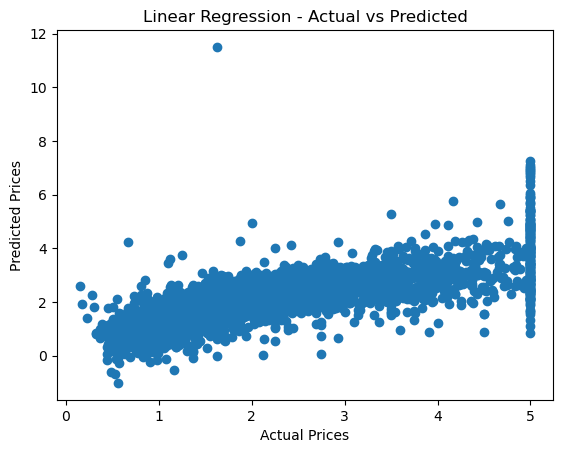

In [12]:
plt.scatter(y_test, y_pred_lr)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Linear Regression - Actual vs Predicted")
plt.show()

## conclusion
-Ridge Regression improvedperformance slightly.
-Decision Tree gave different R2 and may overfit.
-Feature scaling improved linear models.
-performance was compared using RMSE and R2.

In [14]:
results = {
    "Model":["Linear Regression", "Ridge Regression", "Decision Tree"],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
        np.sqrt(mean_squared_error(y_test, y_pred_dt))
    ],
    "R2 score":[
             r2_score(y_test, y_pred_lr),
             r2_score(y_test, y_pred_ridge),
             r2_score(y_test, y_pred_dt)
     ]
}
comparison_df = pd.DataFrame(results)
comparison_df

        

,Model,RMSE,R2 score
0,Linear Regression,0.745581,0.575788
1,Ridge Regression,0.745557,0.575816
2,Decision Tree,0.703729,0.622076


## Model Performance Analysis 
-Lower RMSE indicates better prediction accuracy.
-Higher R2 score indicates better model performance.
-Ridge Regression slightly improves performance over Linear Regression.
-Decision Tree may show high R2 but can overfit.